In [ ]:
from herramientas_opti import *
import seaborn as sns
import matplotlib.pyplot as plt

## Funciones auxiliares

In [2]:
def modelo():
    # Dimensiones del problema
    Nx = 2
    Nu = 0
    Nw = 1
    Ny = 1
    Nv = Ny
    # Parámetros y variables del problema
    x = cs.SX.sym('x', Nx)
    u = cs.SX.sym('u', Nu)
    w = cs.SX.sym('w', Nw)
    # Variables del problema
    a = 0.5
    b = 1

    # Función de estados y de medición
    f_rhs = cs.vertcat(0.99*x[0] + 0.2*x[1],
                   -0.1*x[0] + (a*x[1])/(b+x[1]**2) + w)
    h_rhs = x[0] - 3*x[1]

    f = cs.Function('f_discrete', [x, u, w], [f_rhs], ['x', 'u', 'w'], ['f_rhs'])
    h = cs.Function('h', [x], [h_rhs], ['x'], ['h_rhs'])
    return f, h

def simular(N, Nsim, x0, sigma_w, sigma_v, u, f, h, 
            seed = 0, outliers = False, w_pos = False):
    """Función que simula un sistema discreto, donde:
        N es un diccionario con las dimensiones del sistema, donde:
            N['x'] es la cantidad de estados
            N['y'] es la cantidad de mediciones
            N['w'] es la cantidad de ruido de proceso (si no se especifica, es igual a N['x'])
            N['v'] es la cantidad de ruido de medición (siempre es igual a N['y'])
        Nsim es la cantidad de pasos de tiempo a simular
        x0 es el estado inicial
        sigma_w es la desviación estándar del ruido de proceso
        sigma_v es la desviación estándar del ruido de medición
        u es la entrada al sistema
        f es la función de proceso
        h es la función de medición
        seed es la semilla para la generación de números aleatorios
        outliers es una tupla con la desviación estándar y la probabilidad de outliers
        w_pos es un booleano que indica si el ruido de proceso es positivo (True) o no (False)
       Y devuelve:
        y_sim la salida simulada
        x_sim los estados simulados
        w_sim el ruido de proceso
        v_sim el ruido de medición
        y_clean la salida limpia
    """

    # Defino dimensiones del sistema
    if 'w' not in N:
            N['w'] = N['x']
    N['v'] = N['y']

    x_sim = np.zeros((N['x'], Nsim))
    x_sim[:, 0] = x0
    y_sim = np.zeros((N['y'], Nsim))
    y_clean = np.zeros((N['y'], Nsim))

    np.random.seed(seed)
    # genero ruidos
    w_sim = sigma_w*np.random.randn(N['w'], Nsim-1)
    v_sim = sigma_v*np.random.randn(N['v'], Nsim)
    
    # positivizo ruido de proceso
    if w_pos:
        w_sim = np.abs(w_sim)

    #  agrego outliers a v
    if outliers:
        np.random.seed(seed+10)
        sigma, p = outliers[0], outliers[1]
        inds = np.random.rand(Nsim) <= p # índices de los outliers
        v_sim[:,inds] = sigma*np.random.randn(N['v'],Nsim)[:,inds] # agrego outliers con desvío sigma

    # simulo
    for j in range(Nsim-1):
        y_clean[:, j] = h(x_sim[:, j])
        x_sim[:, j + 1] = f(x_sim[:, j], u[:, j], w_sim[:, j]).full().flatten()
    # último paso de tiempo
    y_clean[:, Nsim-1] = h(x_sim[:, Nsim-1])
    y_sim = y_clean + v_sim
    return y_sim, x_sim, w_sim, v_sim, y_clean

## Parámetros del sistema

In [3]:
Nx = 2 # Cantidad de estados
Nu = 0 # Cantidad de entradas
Nw = 1 # Cantidad de ruido de proceso
Ny = 1 # Cantidad de mediciones
Nv = Ny # Cantidad de ruido de medición
Nsim = 100 # Longitud de la simulación
dt = 1 # Paso de muestreo
t = np.arange(0, Nsim*dt, dt) # Vector de tiempos de muestreo
N_dict = {'x':Nx, 'u':Nu, 'y':Ny, 'w':Nw} # Diccionario de dimensiones

f, h = modelo()
sigma_w = 1 # Desviación estándar del ruido de proceso
sigma_v = 0.1 # Desviación estándar del ruido de medición
x0 = np.array([1, 0]) # Estado inicial
u_sim =  cs.DM.zeros(Nu, Nsim-1) # Entrada (no hay en este caso)

N = 10
N_dict['t'] = N
P_0 = cs.DM.eye(Nx) # Matriz de peso de costo de arribo propuesta
x_0 = np.array([0, 0]) # Estado inicial propuesto
Q = sigma_w**2 * cs.DM.eye(Nw) # Matriz de covarianza del ruido del proceso
R = sigma_v**2 * cs.DM.eye(Nv) # Matriz de covarianza del ruido de medición
F, H, W = jacobiano(f, 0), jacobiano(h, 0), jacobiano(f, 2)

# outliers
sigma = 10 # desviación estándar de los outliers
p = .10 # probabilidad de outliers

## Estimación

In [ ]:
T_ekf = [] # Lista para almacenar los tiempos de ejecución del EKF
MSE_ekf = [] # Lista para almacenar los errores cuadráticos medios del EKF
MAX_ekf = [] # Lista para almacenar los errores máximos del EKF
for i in range(100):
    # Simular el sistema con ruido de proceso y de medición
    y_sim, x_sim, _, _, _ = simular(N_dict, Nsim, x0, sigma_w, sigma_v, u_sim, 
                                    f, h, seed = i+157, w_pos=True, 
                                    outliers= (sigma, p))
    
    # Resolver el problema de EKF
    x_ekf, t_ekf, _ = resolver_ekf(N_dict, f, h, x_0, u_sim, y_sim, P_0, Q, R, 
                            f_jacx=F, f_jacw=W, h_jacx=H, w_pos = sigma_w
                            )
    
    T_ekf.append(np.mean(t_ekf))
    MSE_ekf.append(np.square(x_sim - x_ekf).mean())
    MAX_ekf.append(np.max(np.abs(x_sim - x_ekf)))

In [ ]:

print( "|Method| N | MSE  | MAX  | MCT  |")
print( "|------|---|------|------|------|")
print(f"|{'EKF':6}|---|{np.mean(MSE_ekf):6.3f}|{np.mean(MAX_ekf):6.3f}|{1000*np.mean(T_ekf):6.3f}|")

P_0 = cs.DM.eye(Nx)
rho = 0.25
for N_w in (5, 10):
        N_dict['t'] = N_w
        T_mhe = []
        T_huber = []
        MSE_mhe = []
        MSE_huber = []
        MAX_mhe = []
        MAX_huber = []
        for i in range(100):
            # Simular el sistema con ruido de proceso y de medición
            y_sim, x_sim, _, _, _ = simular(N_dict, Nsim, x0, sigma_w, sigma_v, u_sim, 
                                            f, h, seed = i+157, w_pos=True,
                                            outliers= (sigma, p))
            # Resolver el problema de MHE
            x_mhe, _, _, t_mhe, _ = mhe(N_dict, f, h, x_0, u_sim, y_sim, P_0, Q, R,
                                        f_jacx=F,f_jacw=W,h_jacx=H, 
                                        w_pos=True)

            # Resolver el problema de MHE con Huber
            x_huber, _, _, t_huber, _ = mhe(N_dict, f, h, x_0, u_sim, y_sim, P_0, Q, R,
                                        f_jacx=F,f_jacw=W,h_jacx=H, 
                                        rho_huber = rho, w_pos=True)

            # Guardar tiempos de ejecución
            T_mhe.append(np.mean(t_mhe))
            T_huber.append(np.mean(t_huber))
            # Guardar errores
            MSE_mhe.append(np.square(x_sim - x_mhe).mean())
            MSE_huber.append(np.square(x_sim - x_huber).mean())
            MAX_mhe.append(np.max(np.abs(x_sim - x_mhe)))
            MAX_huber.append(np.max(np.abs(x_sim - x_huber)))
        print(f"|{'MHE':6}|{N_w:3}|{np.mean(MSE_mhe):6.3f}|{np.mean(MAX_mhe):6.3f}|{1000*np.mean(T_mhe):6.3f}|")
        print(f"|{'MHE-H':6}|{N_w:3}|{np.mean(MSE_huber):6.3f}|{np.mean(MAX_huber):6.3f}|{1000*np.mean(T_huber):6.3f}|")


print(x)


|Method| N | MSE  | MAX  | MCT  |
|------|---|------|------|------|
|EKF   |  5| 1.015| 5.838| 0.264|
|MHE   |  5| 1.123| 5.617| 1.967|
|MHE-H |  5| 0.345| 1.883| 2.411|
|MHE   | 10| 0.947| 5.625| 2.383|
|MHE-H | 10| 0.289| 1.781| 3.349|



### Ploteo

In [7]:
# Configuración de parámetros para graficar
# labels para cada método:
lab = ['Reference', 'EKF', 'MHE', 'MHE-H']
# Seteo paleta de colores
color_palette = sns.color_palette("muted")
colors = {lab[0]: 'k',
          lab[1]: color_palette[0],
          lab[2]: color_palette[1],
          lab[3]: color_palette[2]
          }
# Tamaño de labels
label_size = 12
# Tamaño de gráficos
figsize = (7, 5)
# Seteo grosor de líneas
lw = 1.5

In [8]:
# Simular el sistema con ruido de proceso y de medición
semilla = 3000

y_sim, x_sim, _, _, _ = simular(N_dict, Nsim, x0, sigma_w, sigma_v, u_sim, 
                                f, h, seed = semilla+157, w_pos=True,
                                outliers= (sigma, p))

x_ekf, _, _ = resolver_ekf(N_dict, f, h, x_0, u_sim, y_sim, P_0, Q, R, 
                        f_jacx=F, f_jacw=W, h_jacx=H, w_pos = sigma_w
                        )

# Resolver el problema de MHE
x_mhe, _, _, _, _ = mhe(N_dict, f, h, x_0, u_sim, y_sim, P_0, Q, R,
                            f_jacx=F,f_jacw=W,h_jacx=H, update_P=uP, 
                            w_pos=True)

# Resolver el problema de MHE con Huber
x_huber, _, _, _, _ = mhe(N_dict, f, h, x_0, u_sim, y_sim, P_0, Q, R,
                            f_jacx=F,f_jacw=W,h_jacx=H, update_P=uP, 
                            rho_huber = best_rho, w_pos=True)

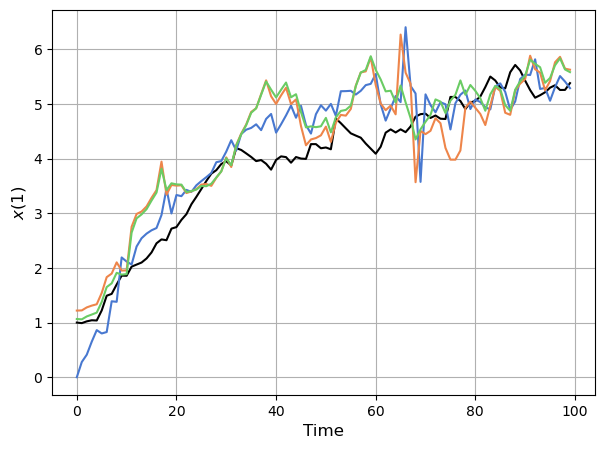

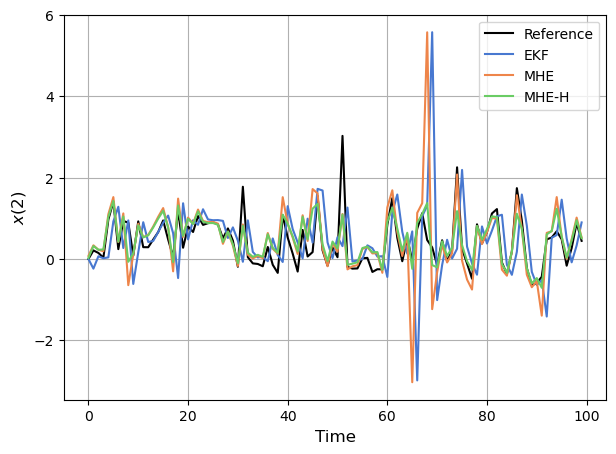

In [9]:
plt.figure(figsize=figsize)
plt.plot(t, x_sim[0,:], label=lab[0], color=colors[lab[0]], linewidth=lw)
plt.plot(t, x_ekf[0,:], label=lab[1], color=colors[lab[1]], linewidth=lw)
plt.plot(t, x_mhe[0,:], label=lab[2], color=colors[lab[2]], linewidth=lw)
plt.plot(t, x_huber[0,:], label=lab[3], color=colors[lab[3]], linewidth=lw)
plt.xlabel('Time', size=label_size)
plt.ylabel('$x(1)$', size=label_size)
plt.grid('on')
# plt.legend()
plt.savefig('nonlinear_x1.pdf', bbox_inches='tight')

plt.figure(figsize=figsize)
plt.plot(t, x_sim[1,:], label=lab[0], color=colors[lab[0]], linewidth=lw)
plt.plot(t, x_ekf[1,:], label=lab[1], color=colors[lab[1]], linewidth=lw)
plt.plot(t, x_mhe[1,:], label=lab[2], color=colors[lab[2]], linewidth=lw)
plt.plot(t, x_huber[1,:], label=lab[3], color=colors[lab[3]], linewidth=lw)
plt.xlabel('Time', size=label_size)
plt.ylabel('$x(2)$', size=label_size)
plt.grid('on')
plt.legend()
plt.savefig('nonlinear_x2.pdf', bbox_inches='tight')
plt.show()

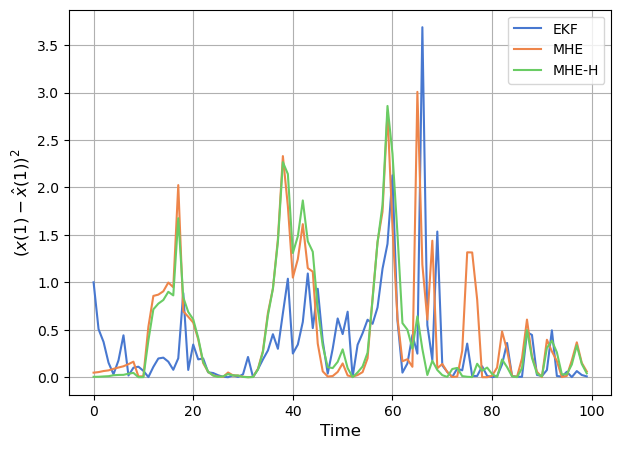

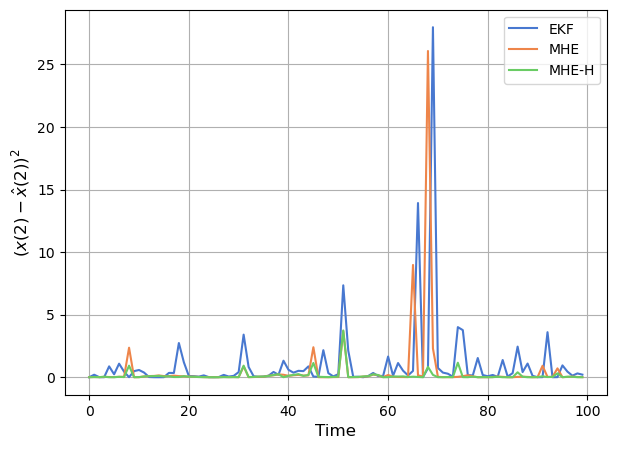

In [10]:
# Ploteo errores cuadráticos
plt.figure(figsize=figsize)
plt.plot((x_sim[0,:] - x_ekf[0,:])**2, label='EKF', color=colors['EKF'], linewidth=lw)
plt.plot((x_sim[0,:] - x_mhe[0,:])**2, label='MHE', color=colors['MHE'], linewidth=lw)
plt.plot((x_sim[0,:] - x_huber[0,:])**2, label='MHE-H', color=colors['MHE-H'], linewidth=lw)
plt.xlabel('Time', size=label_size)
plt.ylabel('$(x(1) - \hat{x}(1))^2$', size=label_size)
plt.grid('on')
plt.legend()
#plt.savefig('nonlinear_error1.pdf', bbox_inches='tight')

plt.figure(figsize=figsize)
plt.plot((x_sim[1,:] - x_ekf[1,:])**2, label='EKF', color=colors['EKF'], linewidth=lw)
plt.plot((x_sim[1,:] - x_mhe[1,:])**2, label='MHE', color=colors['MHE'], linewidth=lw)
plt.plot((x_sim[1,:] - x_huber[1,:])**2, label='MHE-H', color=colors['MHE-H'], linewidth=lw)
plt.xlabel('Time', size=label_size)
plt.ylabel('$(x(2) - \hat{x}(2))^2$', size=label_size)
plt.grid('on')
plt.legend()
#plt.savefig('nonlinear_error2.pdf', bbox_inches='tight')  
plt.show()
